In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import GridSearchCV

# Statistical modeling
import statsmodels.api as sm

# Ignore warnings (clean output)
import warnings
warnings.filterwarnings("ignore")

In [17]:
df = pd.read_csv("data/diabetes.csv")
# lot of missing values hence these columns are dropped
# can we drop pressure?
df = df.drop(columns = ['Insulin', 'SkinThickness'])
df_reduced = df.drop(columns = [ 'BloodPressure', 'Age'])
print("--- df ---")
print(df.head())
# print(df.info())
# print(df.describe())
print("-" * 40)
print("--- df_reduced ---")
print(df_reduced.head())
# print(df_reduced.info())
# print(df_reduced.describe())

--- df ---
   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6      148             72  33.6                     0.627   50   
1            1       85             66  26.6                     0.351   31   
2            8      183             64  23.3                     0.672   32   
3            1       89             66  28.1                     0.167   21   
4            0      137             40  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  
----------------------------------------
--- df_reduced ---
   Pregnancies  Glucose   BMI  DiabetesPedigreeFunction  Outcome
0            6      148  33.6                     0.627        1
1            1       85  26.6                     0.351        0
2            8      183  23.3                     0.672        1
3            1       89  28.1                     0.167        0
4            0      137  43.1                     2

In [3]:
cols_with_zero = ["Glucose", "BloodPressure", "BMI"]
cols_with_zero_reduced = ["Glucose", "BMI"]

# Replace 0 with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df_reduced[cols_with_zero_reduced] = df_reduced[cols_with_zero_reduced].replace(0, np.nan)

for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())
for col in cols_with_zero_reduced:
    df_reduced[col] = df_reduced[col].fillna(df_reduced[col].median())



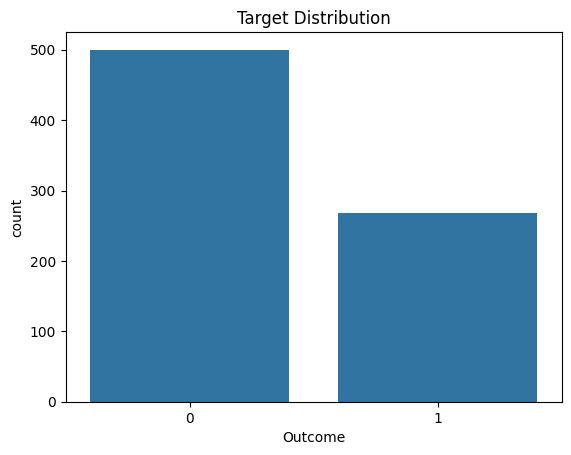

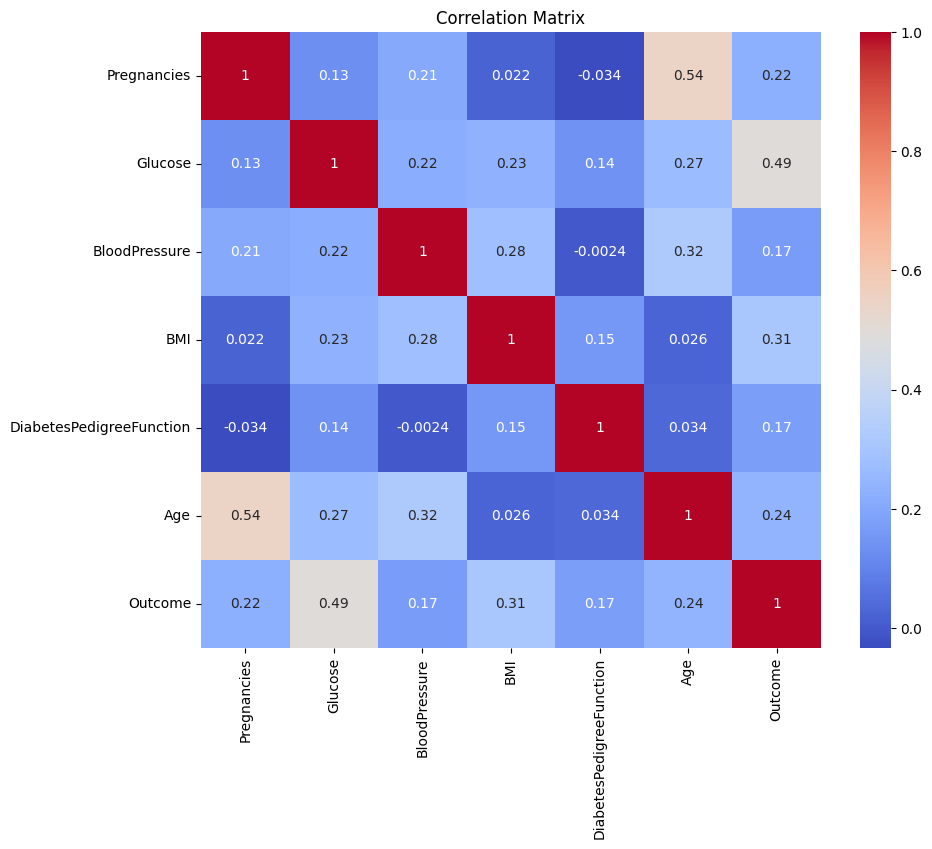

In [4]:
sns.countplot(x=df["Outcome"])
plt.title("Target Distribution")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
X = df.drop("Outcome", axis=1)
X_reduced = df_reduced.drop("Outcome", axis=1)
y = df["Outcome"]
# stratify=y maintains class balance in train/test

test_fraction = 0.15

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_fraction, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y, test_size=test_fraction, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled_reduced = scaler.fit_transform(X_train_reduced)
X_test_scaled_reduced = scaler.transform(X_test_reduced)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# MULTICOLLINEARITY ANALYSIS

def check_multicollinearity(X):
    X_vif = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    print("--- Variance Inflation Factors (VIF) ---")
    print(vif_data)
    print("\nSTATISTICAL INTERPRETATION")
    print("-" * 40)
    # The 'const' VIF is usually high and can be ignored
    max_vif = vif_data.iloc[1:]["VIF"].max() 
    if max_vif < 5:
        print(f"PASS: The maximum VIF is {max_vif:.2f}. Since all VIFs are well below 5,")
        print("there is no significant multicollinearity. This means our coefficient")
        print("estimates (Betas) are stable, and our P-values are reliable.")
    elif max_vif < 10:
        print(f"WARNING: The maximum VIF is {max_vif:.2f}. There is moderate multicollinearity.")
        print("The standard errors of our coefficients are slightly inflated.")
    else:
        print(f"FAIL: The maximum VIF is {max_vif:.2f}. High multicollinearity detected!")
        print("The model coefficients are unstable and difficult to interpret.")
    print("-" * 40)

check_multicollinearity(X_train)

--- Variance Inflation Factors (VIF) ---
                   Variable        VIF
0                     const  53.668036
1               Pregnancies   1.428979
2                   Glucose   1.158298
3             BloodPressure   1.224621
4                       BMI   1.141553
5  DiabetesPedigreeFunction   1.043587
6                       Age   1.604590

STATISTICAL INTERPRETATION
----------------------------------------
PASS: The maximum VIF is 1.60. Since all VIFs are well below 5,
there is no significant multicollinearity. This means our coefficient
estimates (Betas) are stable, and our P-values are reliable.
----------------------------------------


In [21]:
import statsmodels.api as sm

# statsmodels does not include an intercept (constant) by default
# We must add it manually to represent the 'beta_0' of the logistic equation
X_train_const = sm.add_constant(X_train)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

print(result.summary())

p_values = result.pvalues
print("\nStatistically Significant Features (p < 0.05):")
print(p_values[p_values < 0.05])
print("-" * 40)
print("Following features are not significant:", p_values[p_values >= 0.05])
print("-" * 40)

# Fit the Full Model
X_full_const = sm.add_constant(X_train) # Adding constant for intercept
full_model_stats = sm.Logit(y_train, X_full_const).fit(disp=0)

# Fit the Reduced Model (dropping BloodPressure and Age)
X_red_const = sm.add_constant(X_train_reduced) 
reduced_model_stats = sm.Logit(y_train, X_red_const).fit(disp=0)

# Compare AIC and BIC
print(f"Full Model - AIC: {full_model_stats.aic:.2f}, BIC: {full_model_stats.bic:.2f}")
print(f"Reduced Model - AIC: {reduced_model_stats.aic:.2f}, BIC: {reduced_model_stats.bic:.2f}")


if reduced_model_stats.bic < full_model_stats.bic:
    print("\nStatistical Justification:")
    print("The Reduced Model has a lower BIC than the Full Model.")
    print("Since BIC penalizes model complexity more strictly than AIC, the lower BIC ")
    print("provides strong evidence that the reduced model is more parsimonious ")
    print("and better balances model fit with simplicity.")

Optimization terminated successfully.
         Current function value: 0.463485
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  652
Model:                          Logit   Df Residuals:                      645
Method:                           MLE   Df Model:                            6
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.2839
Time:                        18:46:43   Log-Likelihood:                -302.19
converged:                       True   LL-Null:                       -422.01
Covariance Type:            nonrobust   LLR p-value:                 6.709e-49
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -9.3700      0.899    -10.418      0.000     -11.133

In [ ]:
# Extracting coefficients and confidence intervals from the model
params = full_model_stats.params
conf = full_model_stats.conf_int()

# Combining into a summary table
summary_df = pd.concat([params, conf], axis=1)
summary_df.columns = ['Logit_Beta', 'Lower_CI_Logit', 'Upper_CI_Logit']

# Exponentiating to get Odds Ratios and their 95% Confidence Intervals
summary_df['Odds_Ratio'] = np.exp(summary_df['Logit_Beta'])
summary_df['OR_Lower_95'] = np.exp(summary_df['Lower_CI_Logit'])
summary_df['OR_Upper_95'] = np.exp(summary_df['Upper_CI_Logit'])

print(summary_df[['Odds_Ratio', 'OR_Lower_95', 'OR_Upper_95']])

                          Odds_Ratio  OR_Lower_95  OR_Upper_95
const                       0.000085     0.000015     0.000497
Pregnancies                 1.128151     1.052936     1.208738
Glucose                     1.038547     1.030508     1.046649
BloodPressure               0.992553     0.974679     1.010755
BMI                         1.106548     1.070017     1.144326
DiabetesPedigreeFunction    2.103432     1.121475     3.945185
Age                         1.010788     0.990829     1.031148


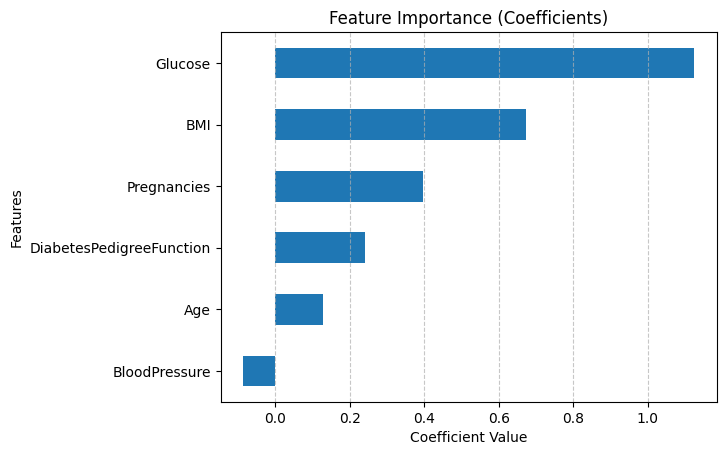

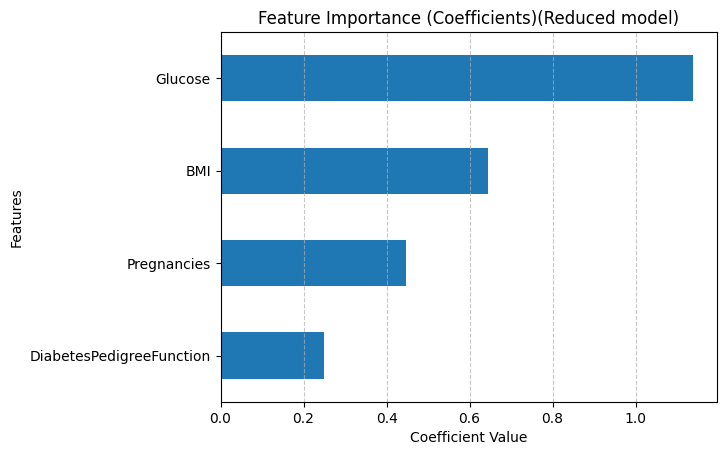

In [8]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
})

coeff_df.set_index('Feature', inplace=True)
coeff_df.sort_values(by="Coefficient").plot(kind='barh', legend=False)
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.show()

model_reduced = LogisticRegression()

model_reduced.fit(X_train_scaled_reduced, y_train_reduced)
coeff_df_reduced = pd.DataFrame({
    "Feature": X_reduced.columns,
    "Coefficient": model_reduced.coef_[0],
})

coeff_df_reduced.set_index('Feature', inplace=True)
coeff_df_reduced.sort_values(by="Coefficient").plot(kind='barh', legend=False)
plt.title("Feature Importance (Coefficients)(Reduced model)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.show()

In [9]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Computing Youden’s J statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
threshold = best_threshold
y_pred_new = (y_prob >= threshold).astype(int)
print("Optimal Threshold: ", threshold)

y_pred_reduced = model_reduced.predict(X_test_scaled_reduced)
y_prob_reduced = model_reduced.predict_proba(X_test_scaled_reduced)[:, 1]

# Computing Youden’s J statistic
fpr, tpr, thresholds = roc_curve(y_test_reduced, y_prob_reduced)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
threshold_reduced = best_threshold
y_pred_new_reduced = (y_prob_reduced >= threshold_reduced).astype(int)
print("Optimal Threshold(Reduced model): ", threshold_reduced)

Optimal Threshold:  0.2862020906946122
Optimal Threshold(Reduced model):  0.26800245738494355



--- Final Performance Comparison ---
   Metric  Full Model (0.5)  Full Model (0.2862)  Reduced Model (0.2680)
 Accuracy          0.724138             0.767241                0.767241
Precision          0.611111             0.610169                0.606557
   Recall          0.550000             0.900000                0.925000
 F1 Score          0.578947             0.727273                0.732673
  AUC-ROC          0.836842             0.836842                0.833224


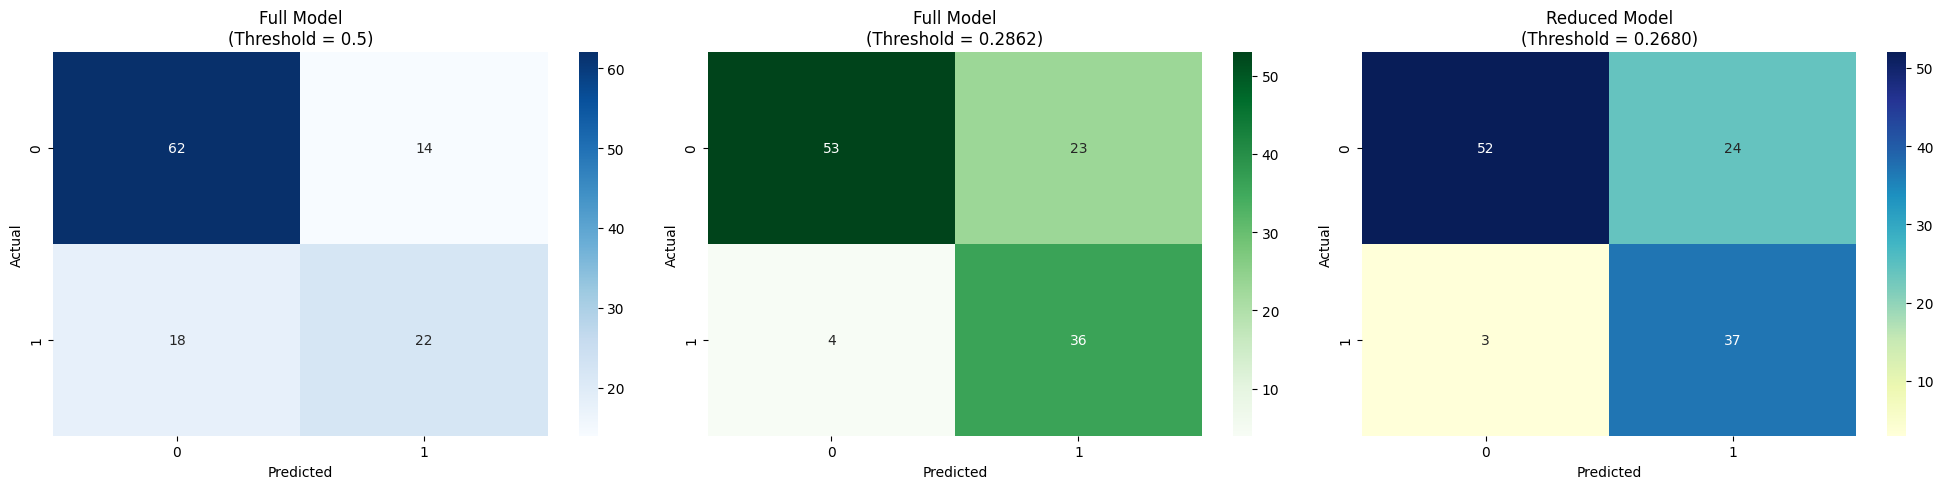

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Function to calculate metrics and return a list
def get_model_metrics(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        roc_auc_score(y_true, y_prob)
    ]

results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"],
    
    "Full Model (0.5)": get_model_metrics(y_test, y_pred, y_prob),
    
    f"Full Model ({threshold:.4f})": get_model_metrics(y_test, y_pred_new, y_prob),
    
    f"Reduced Model ({threshold_reduced:.4f})": get_model_metrics(y_test_reduced, y_pred_new_reduced, y_prob_reduced)
}

# Comparison Table
df_results = pd.DataFrame(results)
print("\n--- Final Performance Comparison ---")
print(df_results.to_string(index=False))

# 3 Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Full Model (0.5)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Full Model\n(Threshold = 0.5)")

# Full Model (Optimal)
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Full Model\n(Threshold = {threshold:.4f})")

# Reduced Model (Optimal)
sns.heatmap(confusion_matrix(y_test_reduced, y_pred_new_reduced), annot=True, fmt="d", cmap="YlGnBu", ax=axes[2])
axes[2].set_title(f"Reduced Model\n(Threshold = {threshold_reduced:.4f})")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()